| Data Type                | Best Graph   |
| ------------------------ | ------------ |
| Numerical (1 column)     | Histogram    |
| Categorical vs Numerical | Boxplot      |
| Numerical vs Numerical   | Scatter Plot |
| Categorical (count)      | Countplot    |


| Column Type           | Encoding         |
| --------------------- | ---------------- |
| Binary (2 categories) | Label Encoding   |
| Ordered Categories    | Ordinal Encoding |
| Unordered Categories  | One-Hot Encoding |


| Method          | Meaning                |
| --------------- | ---------------------- |
| fit()           | Learn from data        |
| transform()     | Apply the learning     |
| fit_transform() | Learn + Apply together |



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/salary.csv")

In [3]:
# ==========================
# Basic Dataset Information
# ==========================

print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(df.shape)

print("\n" + "=" * 50)
print("Column Names")
print("=" * 50)
print(df.columns)

print("\n" + "=" * 50)
print("First 5 Rows")
print("=" * 50)
display(df.head())

print("\n" + "=" * 50)
print("Last 5 Rows")
print("=" * 50)
display(df.tail())

Dataset Shape
(5151, 21)

Column Names
Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Education', 'Department',
       'Job_Title', 'Experience', 'Performance_Rating', 'Overtime',
       'Work_Mode', 'City', 'Company_Size', 'Marital_Status',
       'Certification_Count', 'Skills_Score', 'Years_At_Company',
       'Promotion_Last_5_Years', 'Annual_Bonus', 'Monthly_Salary',
       'Years_at_Company'],
      dtype='str')

First 5 Rows


,Employee_ID,Name,Age,Gender,Education,Department,Job_Title,Experience,Performance_Rating,Overtime,Work_Mode,City,Company_Size,Marital_Status,Certification_Count,Skills_Score,Years_At_Company,Promotion_Last_5_Years,Annual_Bonus,Monthly_Salary,Years_at_Company
0,1619,Lee Wells,NaN,Female,Bachelor's,Operations,Marketing Manager,20.0,4.0,No,Office,Kolkata,Startup,Divorced,8.0,42.0,9,No,70091,150743,NaN
1,2808,John Johnson,23.0,Female,Bachelor's,NaN,Product Manager,3.0,5.0,No,Hybrid,Ahmedabad,Startup,Married,7.0,43.0,1,No,36003,124214,NaN
2,3432,Mr. Roger Daniel MD,25.0,Male,High School,Marketing,Data Scientist,1.0,2.0,Yes,Office,Delhi,Medium,Married,6.0,68.0,0,No,61566,109293,NaN
3,4564,Kathryn Gordon,47.0,Female,Bachelor's,Operations,Database Administrator,21.0,3.0,No,Office,Pune,Enterprise,Married,3.0,48.0,6,No,151696,153653,NaN
4,1947,Jerry Harris,29.0,Male,Diploma,IT,Frontend Developer,0.0,5.0,No,Office,Hyderabad,Large,Single,0.0,86.0,0,No,91634,92969,NaN



Last 5 Rows


,Employee_ID,Name,Age,Gender,Education,Department,Job_Title,Experience,Performance_Rating,Overtime,Work_Mode,City,Company_Size,Marital_Status,Certification_Count,Skills_Score,Years_At_Company,Promotion_Last_5_Years,Annual_Bonus,Monthly_Salary,Years_at_Company
5146,771,Randall Sandoval,25.0,Female,Bachelor's,IT,ML Engineer,NaN,1.0,No,Hybrid,Hyderabad,Medium,Single,4.0,59.0,2,No,169138,111449,NaN
5147,391,Melissa Kaufman,38.0,Female,High School,NaN,Sales Executive,3.0,3.0,No,Office,Ahmedabad,Medium,Married,8.0,86.0,0,Yes,134151,99465,NaN
5148,1578,Joshua Cook,48.0,Female,Bachelor's,Finance,Marketing Executive,8.0,4.0,No,Hybrid,Chennai,Medium,Single,8.0,100.0,4,No,176120,118544,NaN
5149,4814,Joseph Roach,45.0,Female,Bachelor's,Operations,Database Administrator,15.0,4.0,Yes,Office,Ahmedabad,Large,Married,0.0,67.0,3,Yes,107108,162019,NaN
5150,3881,Danny Garrett,26.0,Male,High School,Legal,Data Engineer,6.0,3.0,No,Office,Ahmedabad,Medium,Single,4.0,98.0,3,No,102818,110825,NaN


In [4]:
print("=" * 50)
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 5151 entries, 0 to 5150
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             5151 non-null   int64  
 1   Name                    5151 non-null   str    
 2   Age                     4848 non-null   float64
 3   Gender                  5151 non-null   str    
 4   Education               4847 non-null   str    
 5   Department              4846 non-null   str    
 6   Job_Title               5151 non-null   str    
 7   Experience              4851 non-null   float64
 8   Performance_Rating      4847 non-null   float64
 9   Overtime                5151 non-null   str    
 10  Work_Mode               4850 non-null   str    
 11  City                    5151 non-null   str    
 12  Company_Size            5151 non-null   str    
 13  Marital_Status          5151 non-null   str    
 14  Certification_Count     4851 no

In [5]:
print("=" * 50)
print("Statistical Summary")
print("=" * 50)

display(df.describe())

Statistical Summary


,Employee_ID,Age,Experience,Performance_Rating,Certification_Count,Skills_Score,Years_At_Company,Annual_Bonus,Monthly_Salary,Years_at_Company
count,5151.000000,4848.000000,4851.000000,4847.000000,4851.000000,4851.000000,5151.000000,5151.000000,5151.000000,0.0
mean,2493.711901,40.678012,10.185529,2.990510,5.056277,69.864152,4.591536,114494.140361,141677.502038,NaN
std,1445.122849,11.624572,8.910379,1.414911,3.137260,17.460586,5.039891,69030.607056,52058.276855,NaN
min,1.000000,21.000000,0.000000,1.000000,0.000000,40.000000,0.000000,20037.000000,58531.000000,NaN
25%,1234.500000,30.000000,3.000000,2.000000,2.000000,55.000000,1.000000,64107.500000,112855.000000,NaN
50%,2491.000000,41.000000,8.000000,3.000000,5.000000,70.000000,3.000000,109424.000000,132945.000000,NaN
75%,3744.500000,51.000000,16.000000,4.000000,8.000000,85.000000,7.000000,156766.000000,157677.500000,NaN
max,5000.000000,60.000000,35.000000,5.000000,10.000000,100.000000,20.000000,781004.000000,895524.000000,NaN


In [6]:
# ==========================
# Missing Values Analysis
# ==========================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_values)

,Missing Values,Percentage
Years_at_Company,5151,100.000000
Department,305,5.921180
Performance_Rating,304,5.901767
Education,304,5.901767
Age,303,5.882353
Work_Mode,301,5.843526
Certification_Count,300,5.824112
Experience,300,5.824112
Skills_Score,300,5.824112
Gender,0,0.000000


In [7]:
# ==========================
# Handle Missing Values
# ==========================

# Drop completely empty column
df.drop(columns=["Years_at_Company"], inplace=True)

# Fill numerical columns with Median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median(), inplace=True)
    
# Fill categorical columns with Mode
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0], inplace=True)
    
df.isnull().sum()
    

/var/folders/yd/t3kq8xrn5rz943g01tdmcx8c0000gn/T/ipykernel_6202/2921460551.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col] = df[col].fillna(df[col].median(), inplace=True)
/var/folders/yd/t3kq8xrn5rz943g01tdmcx8c0000gn/T/ipykernel_6202/2921460551.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFram

Employee_ID               0
Name                      0
Age                       0
Gender                    0
Education                 0
Department                0
Job_Title                 0
Experience                0
Performance_Rating        0
Overtime                  0
Work_Mode                 0
City                      0
Company_Size              0
Marital_Status            0
Certification_Count       0
Skills_Score              0
Years_At_Company          0
Promotion_Last_5_Years    0
Annual_Bonus              0
Monthly_Salary            0
dtype: int64

In [8]:
# ==========================
# Check Duplicate Rows
# ==========================

duplicate_count = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_count}")

Total Duplicate Rows: 116


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

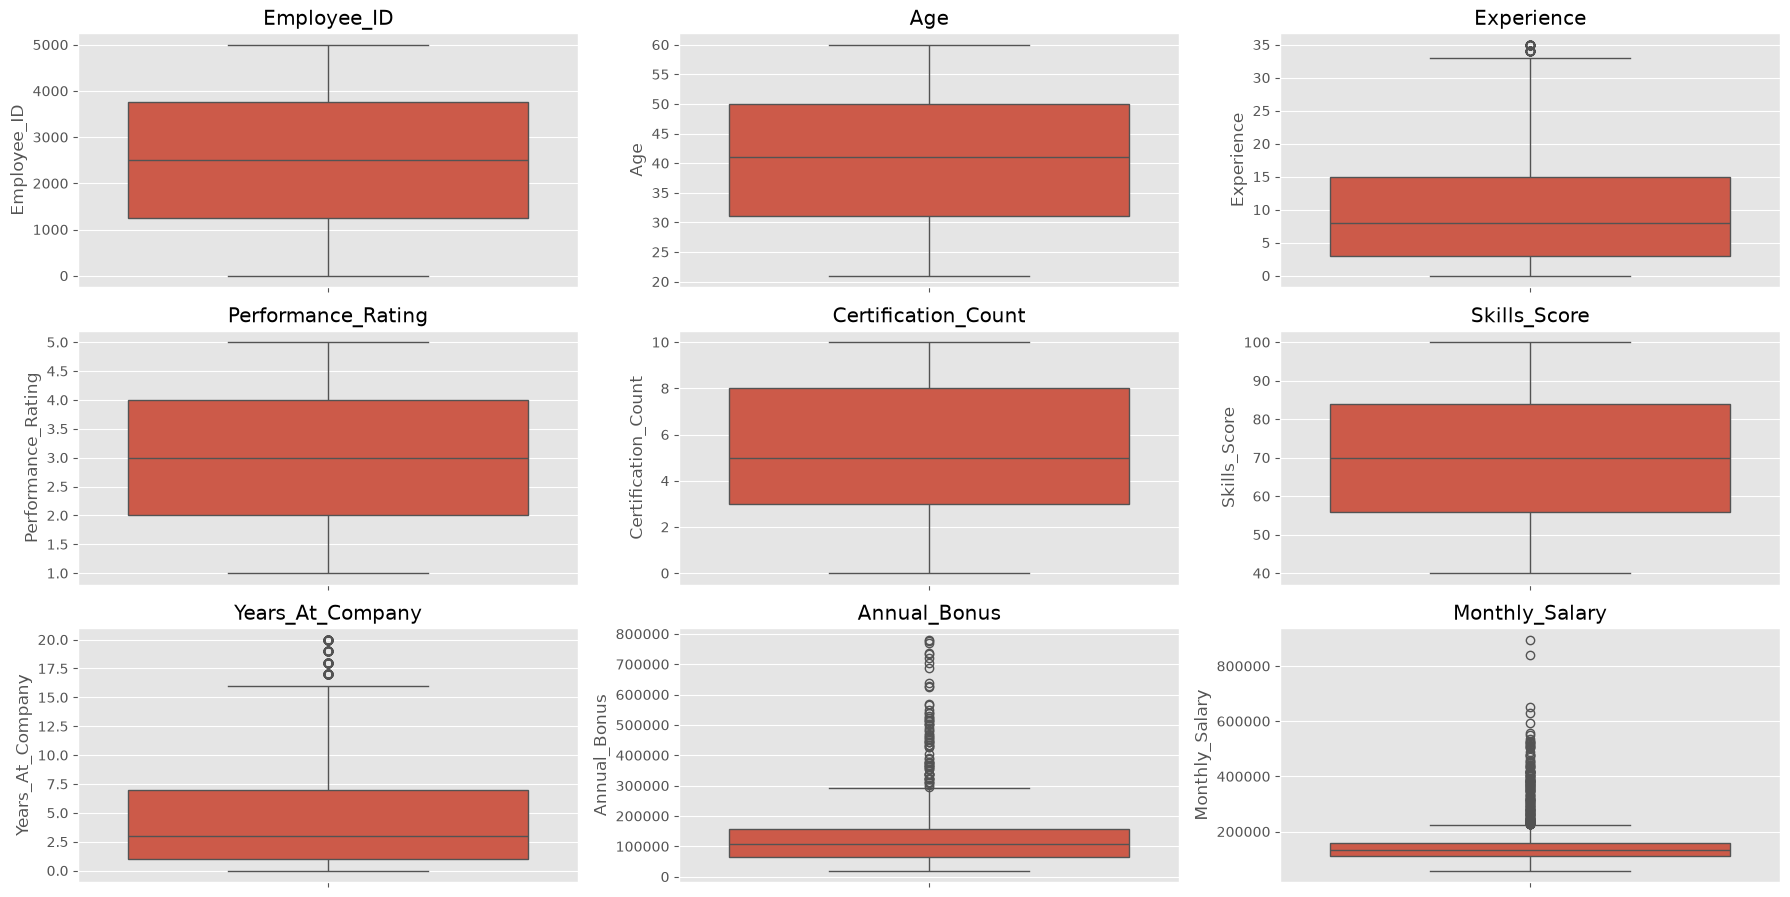

In [11]:
# ==========================
# Boxplots for Numerical Columns
# ==========================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Plot boxplots
plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
    
plt.tight_layout()
plt.show()

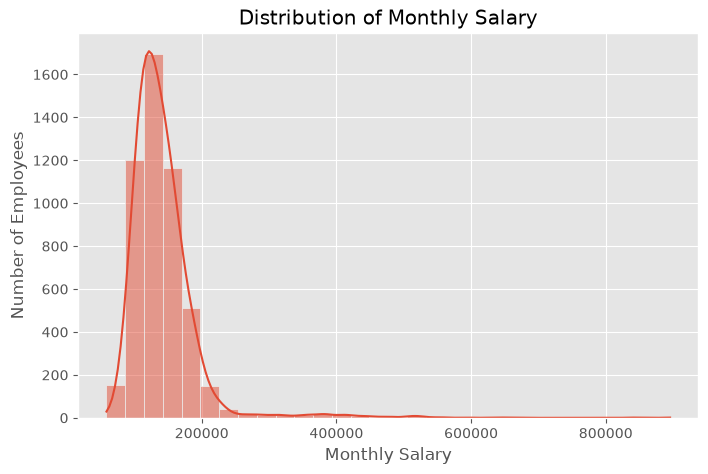

In [12]:
# ==========================
# Distribution of Target Variable
# ==========================

plt.figure(figsize=(8, 5))
sns.histplot(df["Monthly_Salary"], bins=30, kde=True)
plt.title("Distribution of Monthly Salary")
plt.xlabel("Monthly Salary")
plt.ylabel("Number of Employees")
plt.show()

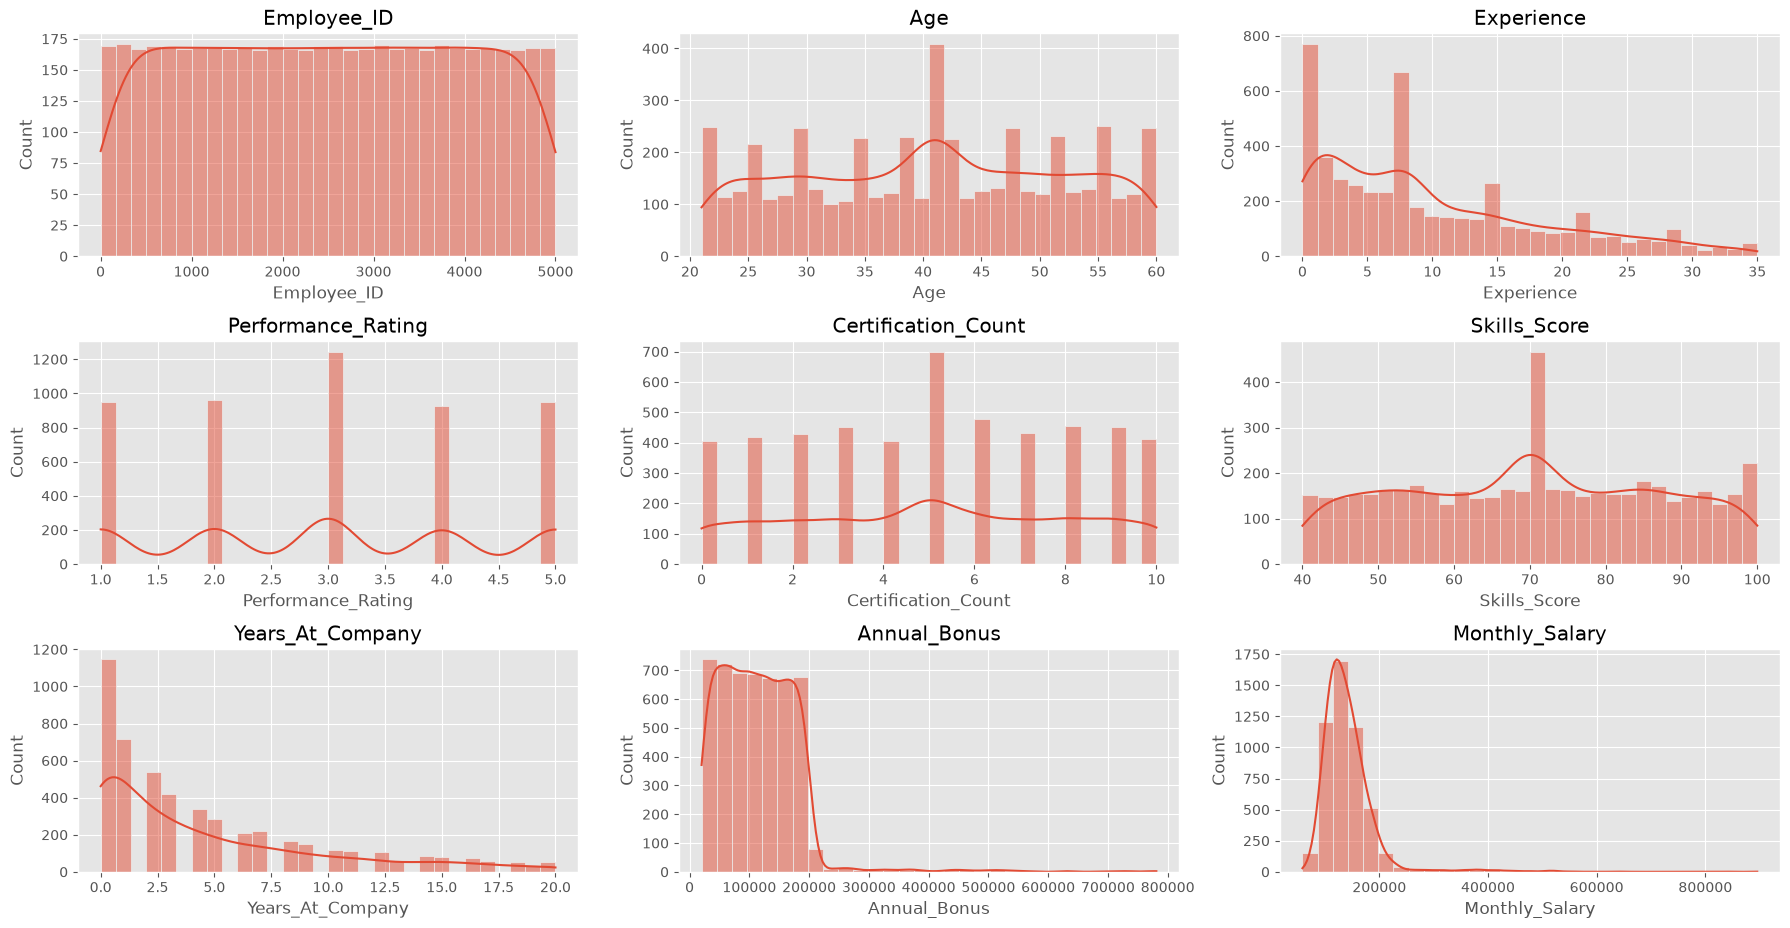

In [13]:
# ==========================
# Distribution of Numerical Features
# ==========================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    
plt.tight_layout()
plt.show()

In [14]:
df.dtypes

Employee_ID                 int64
Name                          str
Age                       float64
Gender                        str
Education                     str
Department                    str
Job_Title                     str
Experience                float64
Performance_Rating        float64
Overtime                      str
Work_Mode                     str
City                          str
Company_Size                  str
Marital_Status                str
Certification_Count       float64
Skills_Score              float64
Years_At_Company            int64
Promotion_Last_5_Years        str
Annual_Bonus                int64
Monthly_Salary              int64
dtype: object

In [15]:
# Convert all string columns to object dtype

str_columns = df.select_dtypes(include=["str"]).columns

df[str_columns] = df[str_columns].astype("object")

df.drop(columns=["Name"], inplace=True)

print(df.dtypes)

Employee_ID                 int64
Age                       float64
Gender                     object
Education                  object
Department                 object
Job_Title                  object
Experience                float64
Performance_Rating        float64
Overtime                   object
Work_Mode                  object
City                       object
Company_Size               object
Marital_Status             object
Certification_Count       float64
Skills_Score              float64
Years_At_Company            int64
Promotion_Last_5_Years     object
Annual_Bonus                int64
Monthly_Salary              int64
dtype: object


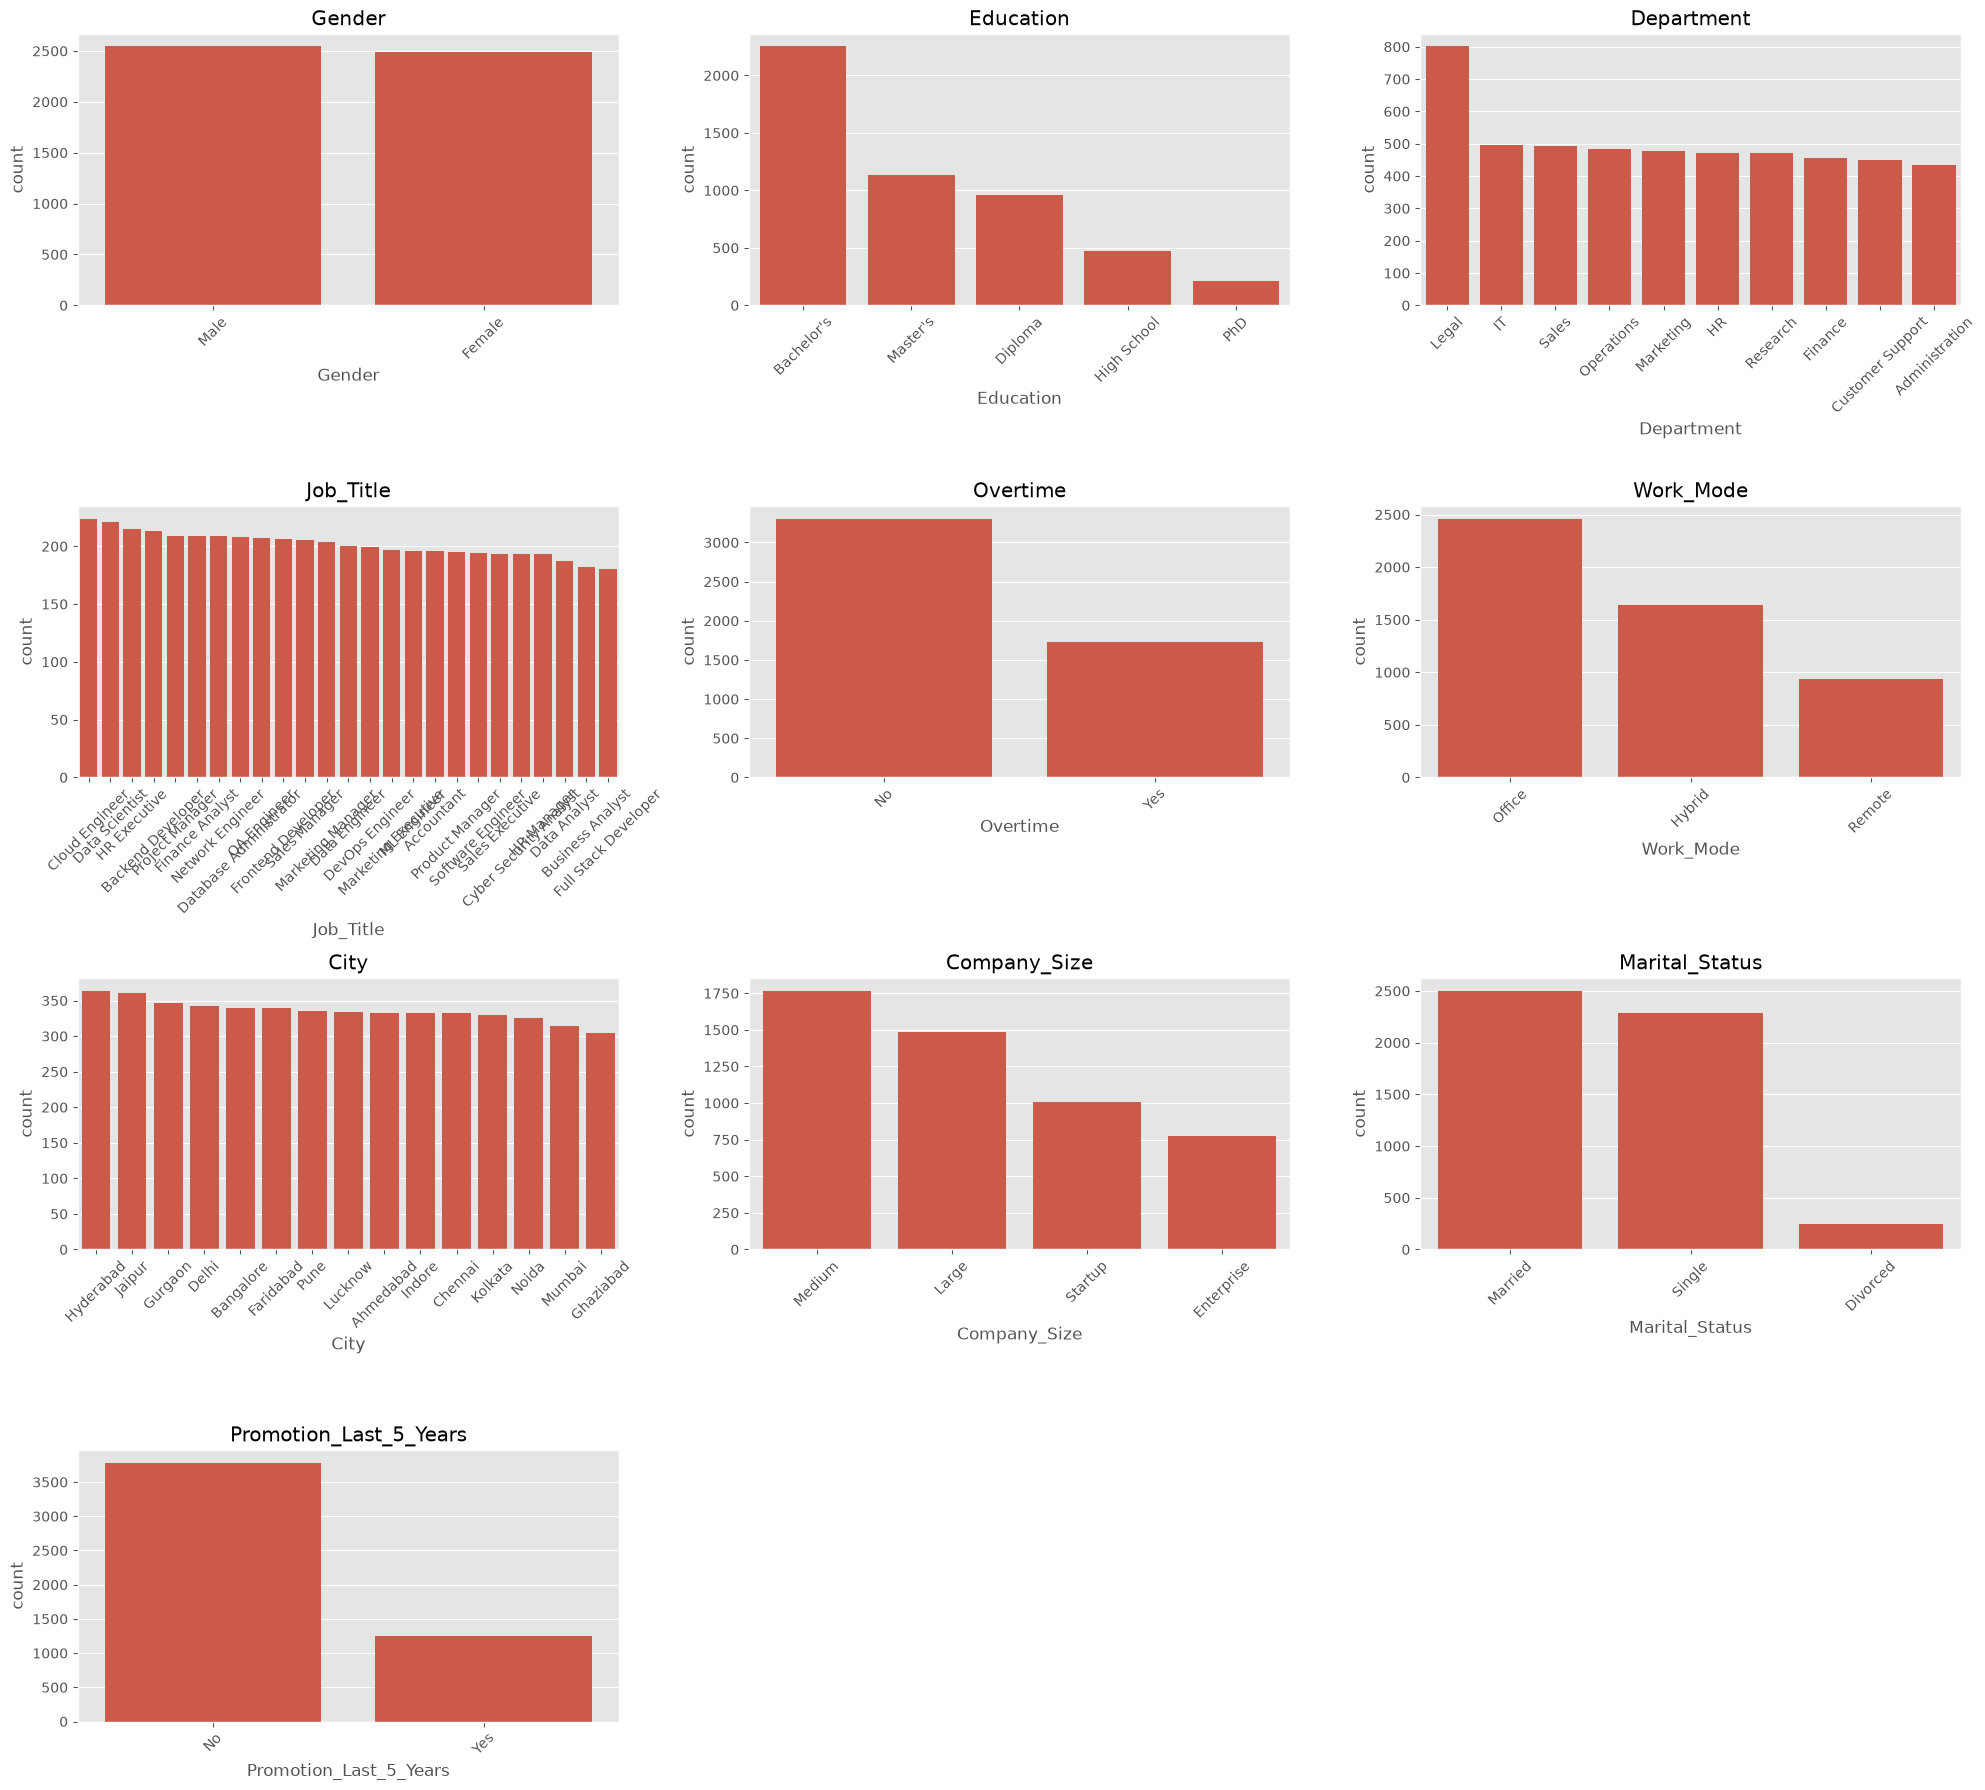

In [16]:
# ==========================
# Count Plot for Categorical Features
# ==========================

categorical_columns = df.select_dtypes(include=["object"]).columns

plt.figure(figsize=(20, 18))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(4, 3, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

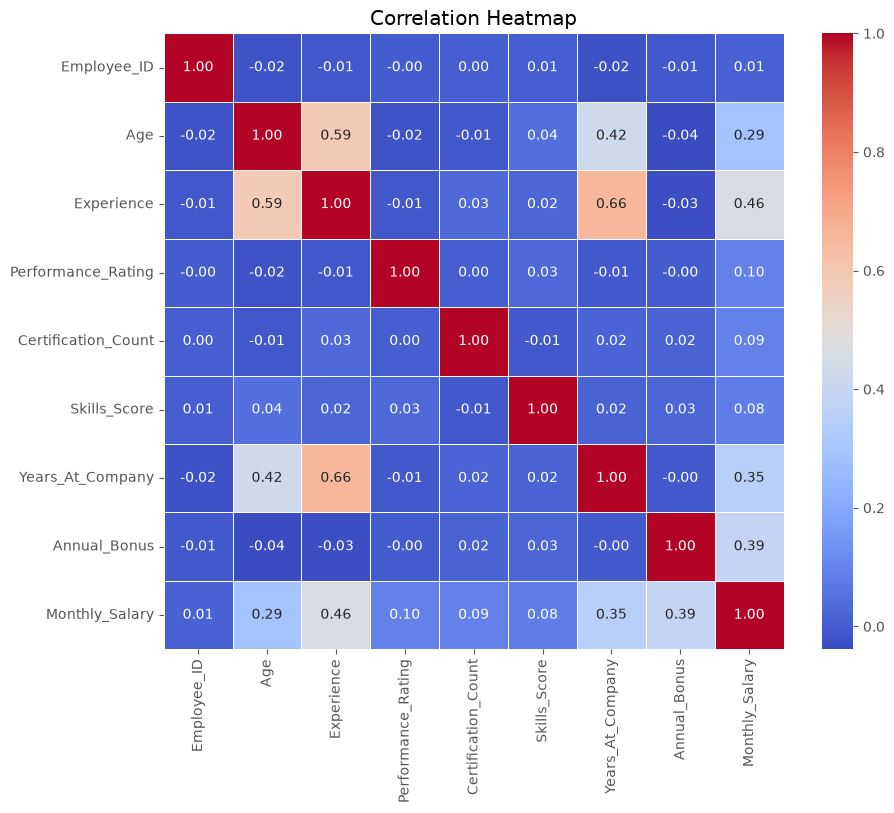

In [17]:
# ==========================
# Correlation Heatmap
# ==========================

# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

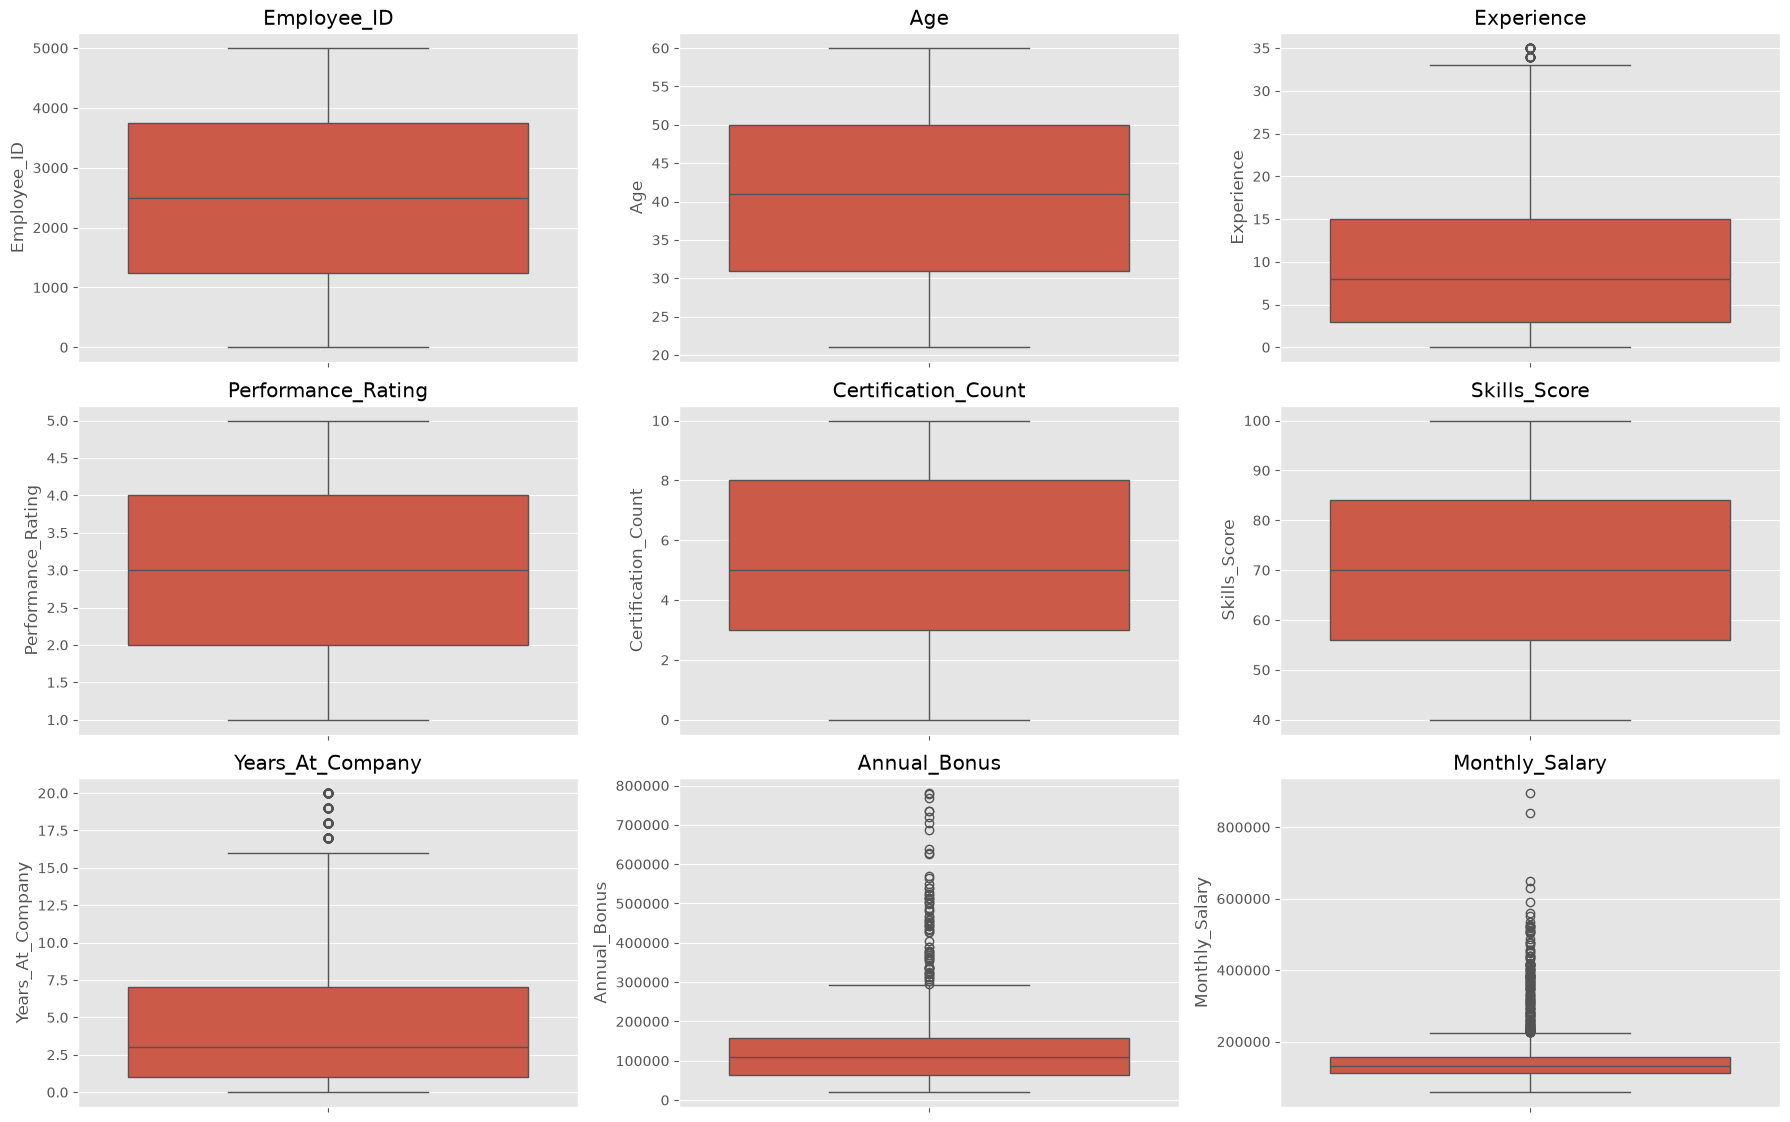

In [18]:
# ==========================
# Boxplots for Numerical Columns
# ==========================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
    
plt.tight_layout()
plt.show()

In [19]:
# ==========================
# Count Outliers (IQR Method)
# ==========================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = []

for col in numerical_columns:
    # Skip columns that are completely empty
    if df[col].isnull().all():
        continue
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append(
        {
            "Column" : col,
            "Outliers" : len(outliers),
            "Percentage (%)" : round((len(outliers) / len(df)) * 100, 2)
        }
    )
    
outlier_df = pd.DataFrame(outlier_summary).sort_values(
    by = "Outliers",
    ascending = False
)

display(outlier_df)

,Column,Outliers,Percentage (%)
6,Years_At_Company,203,4.03
8,Monthly_Salary,162,3.22
7,Annual_Bonus,69,1.37
2,Experience,47,0.93
0,Employee_ID,0,0.00
4,Certification_Count,0,0.00
3,Performance_Rating,0,0.00
1,Age,0,0.00
5,Skills_Score,0,0.00


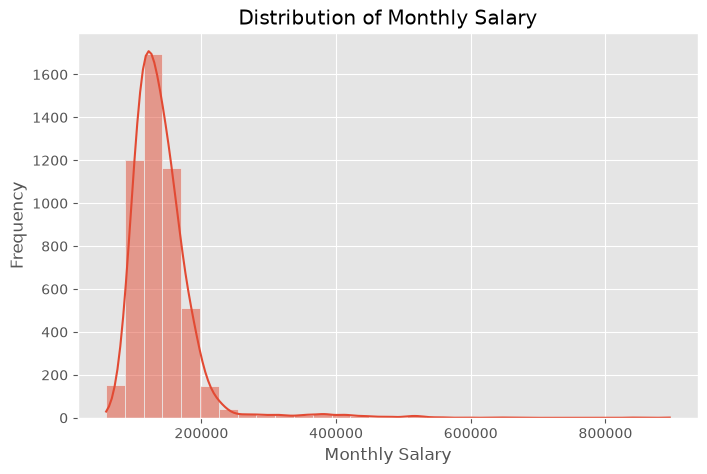

In [20]:
# ==========================
# Distribution of Target Variable
# ==========================

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Monthly_Salary", bins=30, kde=True)
plt.title("Distribution of Monthly Salary")
plt.xlabel("Monthly Salary")
plt.ylabel("Frequency")
plt.show()

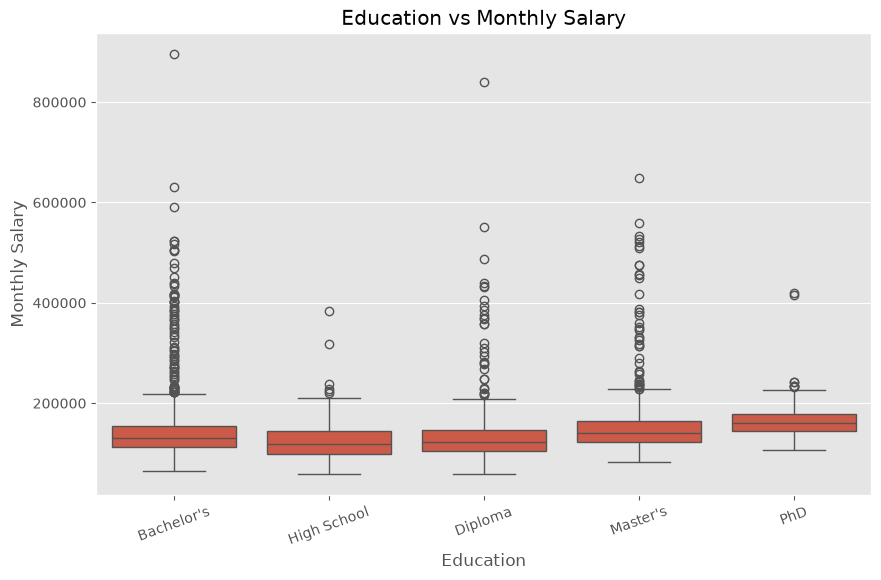

In [21]:
# ==========================
# Education vs Monthly Salary
# ==========================

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Education", y="Monthly_Salary")
plt.title("Education vs Monthly Salary")
plt.xlabel("Education")
plt.ylabel("Monthly Salary")
plt.xticks(rotation=20)
plt.show()

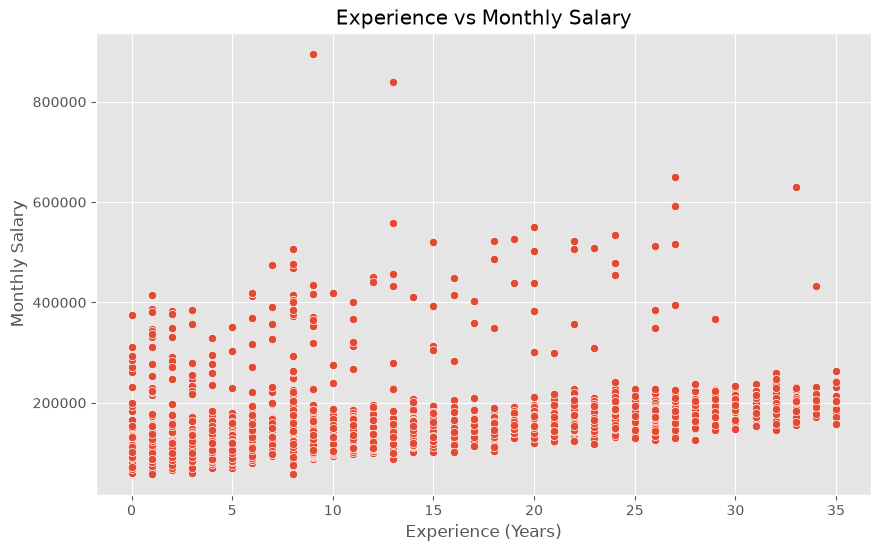

In [22]:
# ==========================
# Experience vs Monthly Salary
# ==========================

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Experience", y="Monthly_Salary")
plt.title("Experience vs Monthly Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Monthly Salary")
plt.show()

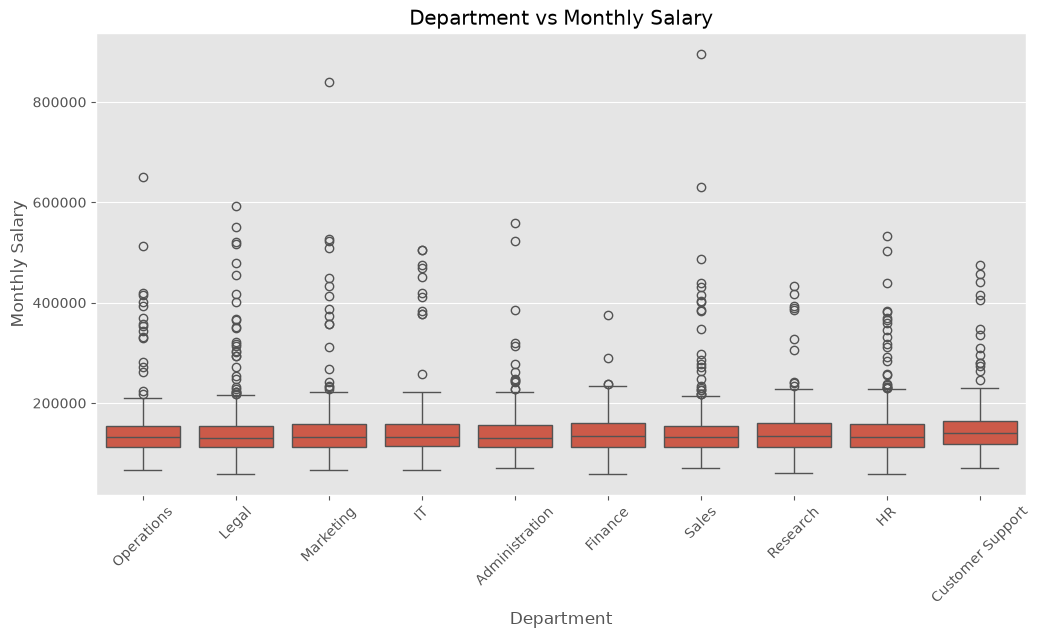

In [23]:
# ==========================
# Department vs Monthly Salary
# ==========================

plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="Department", y="Monthly_Salary")
plt.title("Department vs Monthly Salary")
plt.ylabel("Monthly Salary")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.show()

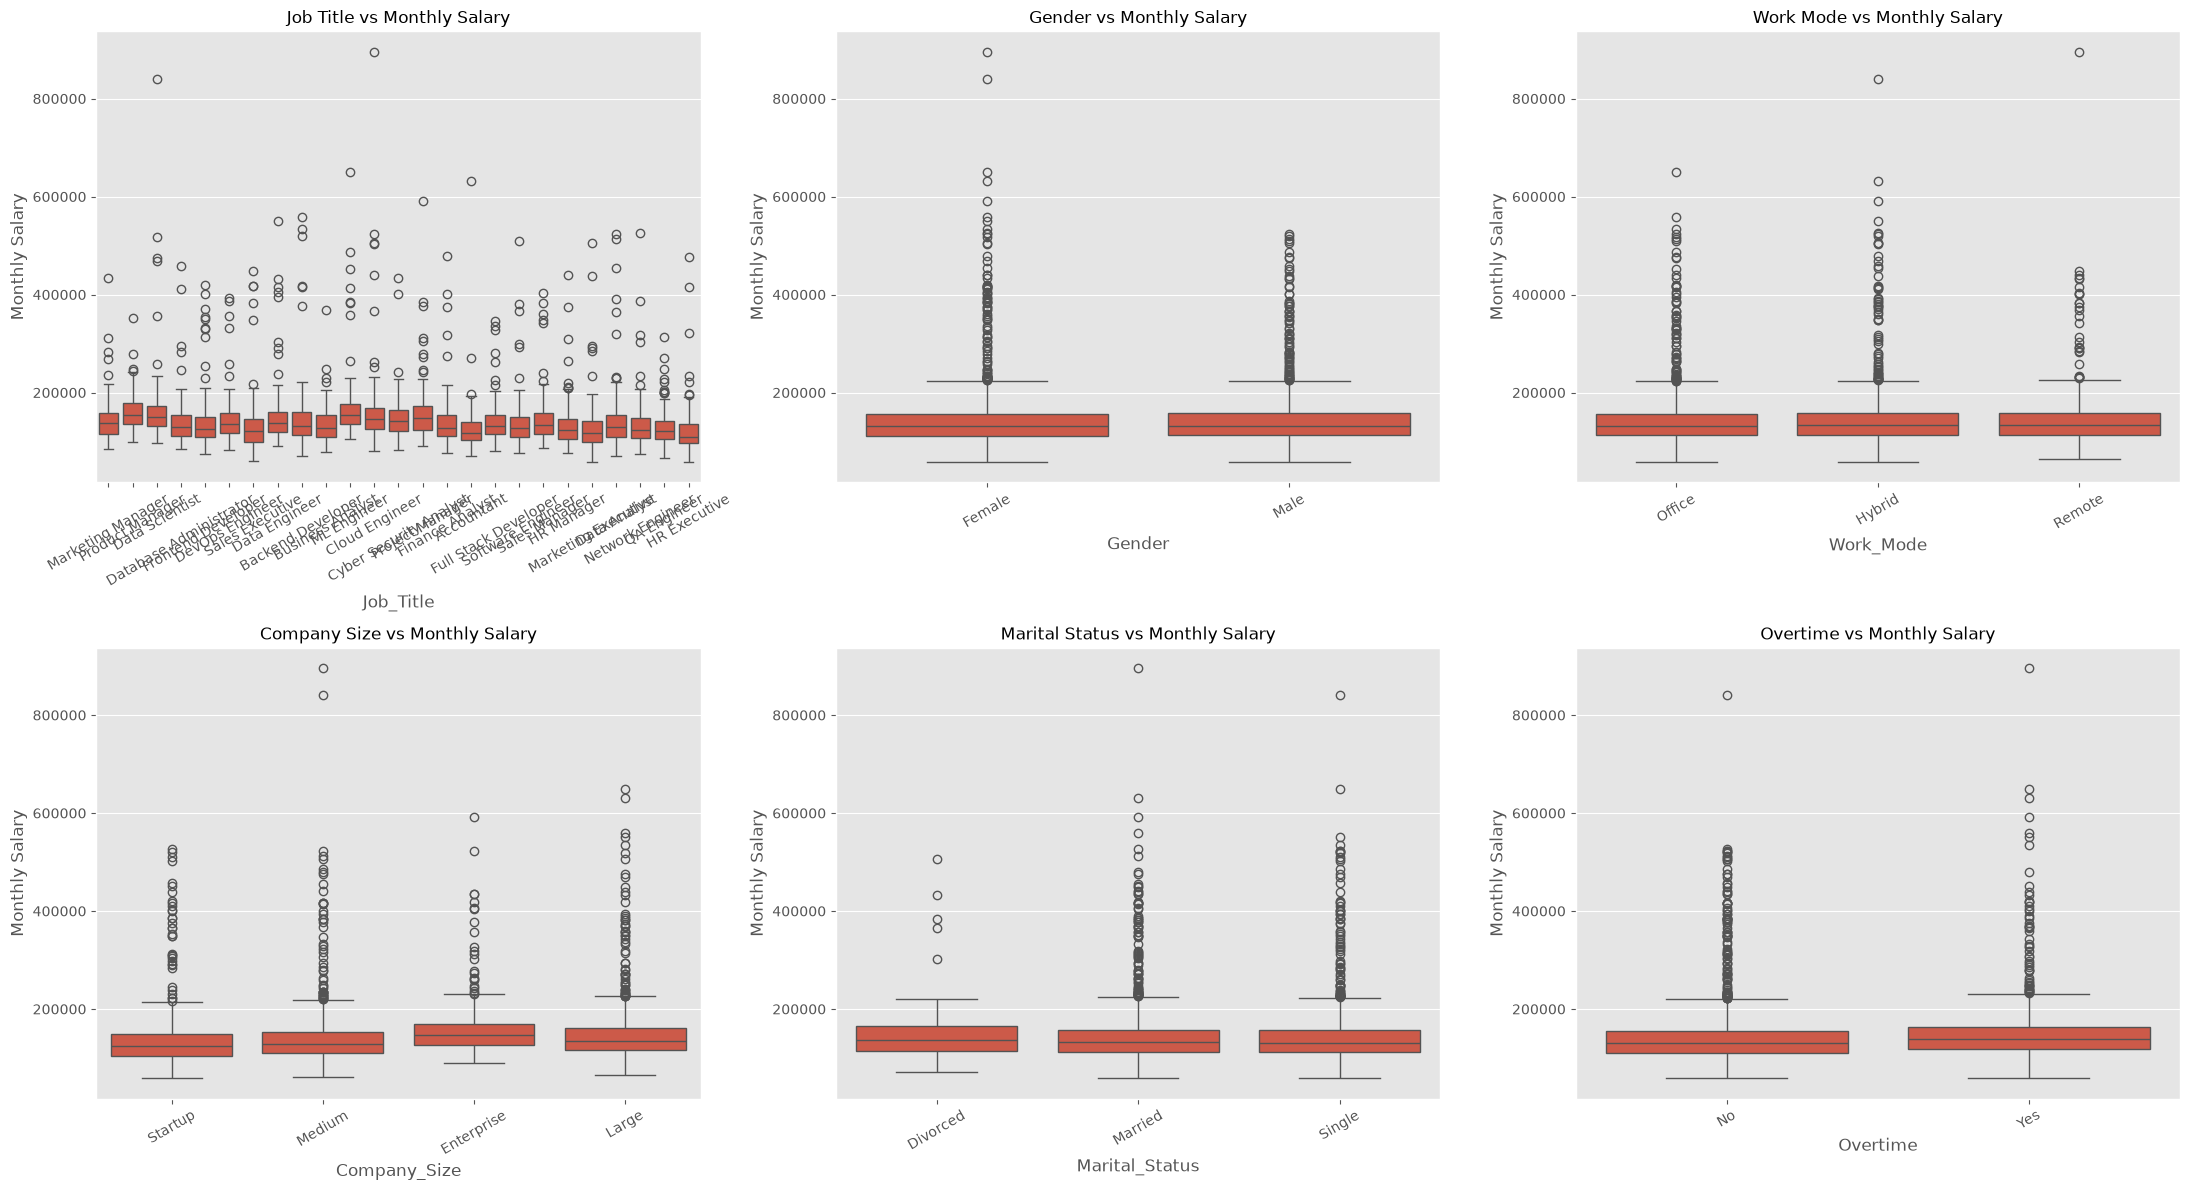

In [24]:
# ==========================
# Remaining EDA (Categorical Features vs Monthly Salary)
# ==========================

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
plots = [
    ("Job_Title", "Job Title vs Monthly Salary"),
    ("Gender", "Gender vs Monthly Salary"),
    ("Work_Mode", "Work Mode vs Monthly Salary"),
    ("Company_Size", "Company Size vs Monthly Salary"),
    ("Marital_Status", "Marital Status vs Monthly Salary"),
    ("Overtime", "Overtime vs Monthly Salary")
]

for ax, (col, title) in zip(axes.flat, plots):
    sns.boxplot(data=df, x=col, y="Monthly_Salary", ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Monthly Salary")
    ax.tick_params(axis="x", rotation=30)
    
plt.tight_layout()
plt.show()

| Column                 | Encoding | Reason            |
| ---------------------- | -------- | ----------------- |
| Education              | Ordinal  | Natural order hai |
| Company_Size           | Ordinal  | Size ka order hai |
| Gender                 | One-Hot  | No ranking        |
| Department             | One-Hot  | No ranking        |
| Job_Title              | One-Hot  | No ranking        |
| Overtime               | One-Hot  | Yes/No category   |
| Work_Mode              | One-Hot  | No ranking        |
| City                   | One-Hot  | No ranking        |
| Marital_Status         | One-Hot  | No ranking        |
| Promotion_Last_5_Years | One-Hot  | Yes/No category   |


In [25]:
# ==========================
# Define Categorical Columns
# ==========================

# Ordinal Features (Order Exists)
ordinal_features = [
    "Education",
    "Company_Size"
]

# Nominal Features (No Order)
nominal_features = [
    "Gender",
    "Department", 
    "Job_Title",
    "Overtime",
    "Work_Mode",
    "City",
    "Marital_Status",
    "Promotion_Last_5_Years"
]

print("Ordinal Features:")
print(ordinal_features)

print("\nNominal Features:")
print(nominal_features)

Ordinal Features:
['Education', 'Company_Size']

Nominal Features:
['Gender', 'Department', 'Job_Title', 'Overtime', 'Work_Mode', 'City', 'Marital_Status', 'Promotion_Last_5_Years']


In [26]:
# ==========================
# Import Encoding Libraries
# ==========================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [27]:
# ==========================
# Define Order for Ordinal Features
# ==========================
education_order = [
    "High School",
    "Diploma",
    "Bachelor's",
    "Master's",
    "PhD"
]

company_size_order = [
    "Startup",
    "Medium",
    "Large",
    "Enterprise"
]

In [28]:
# ==========================
# Create Column Transformer
# ==========================

preprocessor = ColumnTransformer(
    transformers = [
        (
            "ordinal",
            OrdinalEncoder(
                categories = [
                    education_order,
                    company_size_order
                ]
            ),
            ordinal_features
        ),
        
        (
            "nomial",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        )
    ],
    remainder="passthrough"
)

In [29]:
# ==========================
# Define Features (X) and Target (y)
# ==========================

X = df.drop(columns=["Monthly_Salary", "Employee_ID"])
y = df["Monthly_Salary"]

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (5035, 17)
Shape of y : (5035,)


In [30]:
# ==========================
# Train-Test Split
# ==========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (4028, 17)
X_test  : (1007, 17)
y_train : (4028,)
y_test  : (1007,)


In [31]:
# ==========================
# Apply Preprocessing
# ==========================

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("Encoded X_train Shape :", X_train.shape)
print("Encoded X_test Shape  :", X_test.shape)

Encoded X_train Shape : (4028, 71)
Encoded X_test Shape  : (1007, 71)


In [32]:
# ==========================
# Train Linear Regression Model
# ==========================

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [33]:
# ==========================
# Prediction
# ==========================

y_pred_lr = lr_model.predict(X_test)
print(y_pred_lr[:10])

[ 90399.40236478 173077.71567819 132426.80038761  98548.71500262
 162285.29372668 192580.71473986 158750.63730398 152493.35087258
 103492.39571322 208441.44662059]


In [34]:
# ==========================
# Evaluate Linear Regression
# ==========================

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 20505.74
MSE  : 1265799920.12
RMSE : 35578.08
R² Score : 0.4779


In [35]:
# ==========================
# Train Decision Tree Regressor
# ==========================

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [36]:
# ==========================
# Prediction
# ==========================
y_pred_dt = dt_model.predict(X_test)
print(y_pred_dt[:10])

[ 99290. 151837. 160055. 113784. 155024. 162920. 129383. 153011.  96067.
 163097.]


In [37]:
# ==========================
# Evaluate Decision Tree
# ==========================

mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = mse_dt ** 0.5

r2_dt = r2_score(y_test, y_pred_dt)

print(f"MAE  : {mae_dt:.2f}")
print(f"MSE  : {mse_dt:.2f}")
print(f"RMSE : {rmse_dt:.2f}")
print(f"R² Score : {r2_dt:.4f}")

MAE  : 19624.35
MSE  : 1383887417.02
RMSE : 37200.64
R² Score : 0.4292


In [38]:
# ==========================
# Model Evaluation Function
# ==========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = mse ** 0.5

    r2 = r2_score(y_test, y_pred)

    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R² Score : {r2:.4f}")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [39]:
# ==========================
# Train Random Forest
# ==========================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [40]:
rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test
)

MAE  : 13195.30
MSE  : 712809768.55
RMSE : 26698.50
R² Score : 0.7060


In [41]:
# ==========================
# Train Extra Trees Regressor
# ==========================

from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    random_state=42
)

et_model.fit(X_train, y_train)

print("Extra Trees Model Trained Successfully!")

Extra Trees Model Trained Successfully!


In [42]:
et_results = evaluate_model(
    et_model,
    X_test,
    y_test
)

MAE  : 12982.39
MSE  : 781796480.71
RMSE : 27960.62
R² Score : 0.6775


In [43]:
# ==========================
# Train Gradient Boosting Regressor
# ==========================

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [44]:
gb_results = evaluate_model(
    gb_model,
    X_test,
    y_test
)

MAE  : 11354.42
MSE  : 654496987.42
RMSE : 25583.14
R² Score : 0.7300


In [45]:
# ==========================
# Model Comparison
# ==========================

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        mae_dt,
        rf_results["MAE"],
        et_results["MAE"],
        gb_results["MAE"]
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rf_results["RMSE"],
        et_results["RMSE"],
        gb_results["RMSE"]
    ],
    "R2 Score": [
        r2,
        r2_dt,
        rf_results["R2"],
        et_results["R2"],
        gb_results["R2"]
    ]
})

comparison_df = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,11354.423933,25583.138733,0.730049
1,Random Forest,13195.296187,26698.497496,0.705998
2,Extra Trees,12982.387885,27960.623754,0.677544
3,Linear Regression,20505.742892,35578.082019,0.477914
4,Decision Tree,19624.351539,37200.637320,0.429209


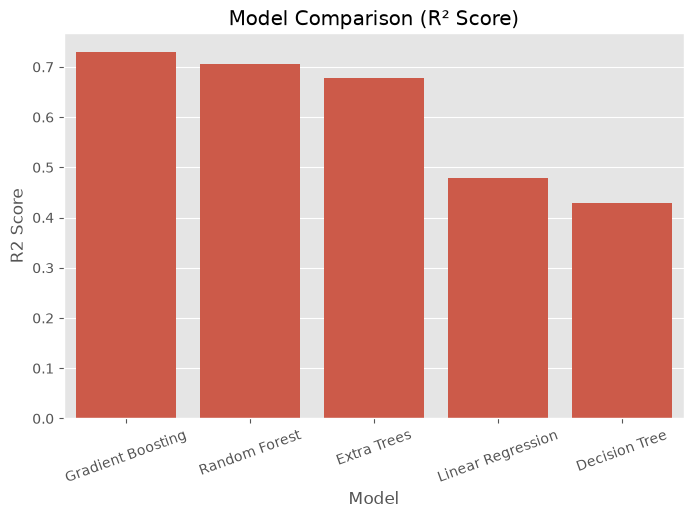

In [46]:
# ==========================
# Model Comparison - R² Score
# ==========================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=20)

plt.show()

In [47]:
# ==========================
# Get Feature Names After Encoding
# ==========================

feature_names = preprocessor.get_feature_names_out()

print("Total Features:", len(feature_names))
print(feature_names[:10])   # First 10 feature names

Total Features: 71
['ordinal__Education' 'ordinal__Company_Size' 'nomial__Gender_Female'
 'nomial__Gender_Male' 'nomial__Department_Administration'
 'nomial__Department_Customer Support' 'nomial__Department_Finance'
 'nomial__Department_HR' 'nomial__Department_IT'
 'nomial__Department_Legal']


In [48]:
# ==========================
# Feature Importance
# ==========================

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
70,remainder__Annual_Bonus,0.521761
65,remainder__Experience,0.255642
0,ordinal__Education,0.048316
1,ordinal__Company_Size,0.021216
66,remainder__Performance_Rating,0.015249
69,remainder__Years_At_Company,0.014482
21,nomial__Job_Title_Data Scientist,0.012813
68,remainder__Skills_Score,0.009787
64,remainder__Age,0.009447
67,remainder__Certification_Count,0.008251


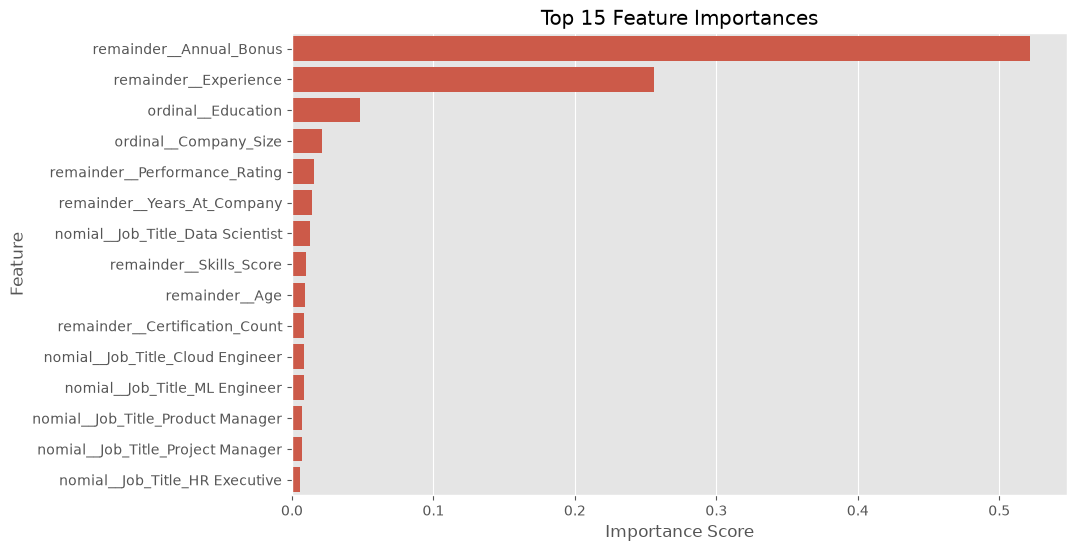

In [49]:
# ==========================
# Top 15 Important Features
# ==========================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [50]:
# ==========================
# Save Model
# ==========================

import joblib

joblib.dump(gb_model, "salary_prediction_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model saved successfully!")
print("Preprocessor saved successfully!")

Model saved successfully!
Preprocessor saved successfully!


In [51]:
# ==========================
# Load Saved Model
# ==========================

loaded_model = joblib.load("salary_prediction_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

print("Saved files loaded successfully!")

Saved files loaded successfully!


In [52]:
# ==========================
# New Employee Data
# ==========================

new_employee = pd.DataFrame({
    "Age": [28],
    "Gender": ["Male"],
    "Education": ["Bachelor's"],
    "Department": ["IT"],
    "Job_Title": ["Software Engineer"],
    "Experience": [5],
    "Performance_Rating": [4],
    "Overtime": ["No"],
    "Work_Mode": ["Hybrid"],
    "City": ["Delhi"],
    "Company_Size": ["Medium"],
    "Marital_Status": ["Single"],
    "Certification_Count": [3],
    "Skills_Score": [82],
    "Years_At_Company": [3],
    "Promotion_Last_5_Years": ["No"],
    "Annual_Bonus": [80000],
    "Employee_ID": [9999]
})

new_employee

,Age,Gender,Education,Department,Job_Title,Experience,Performance_Rating,Overtime,Work_Mode,City,Company_Size,Marital_Status,Certification_Count,Skills_Score,Years_At_Company,Promotion_Last_5_Years,Annual_Bonus,Employee_ID
0,28,Male,Bachelor's,IT,Software Engineer,5,4,No,Hybrid,Delhi,Medium,Single,3,82,3,No,80000,9999


In [53]:
# ==========================
# Apply Preprocessing
# ==========================

new_employee_encoded = loaded_preprocessor.transform(new_employee)

print(new_employee_encoded.shape)

(1, 71)


In [54]:
# ==========================
# Predict Salary
# ==========================

predicted_salary = loaded_model.predict(new_employee_encoded)

print(f"Predicted Monthly Salary: ₹{predicted_salary[0]:,.2f}")

Predicted Monthly Salary: ₹113,259.85


In [55]:
print(X.columns.tolist())

['Age', 'Gender', 'Education', 'Department', 'Job_Title', 'Experience', 'Performance_Rating', 'Overtime', 'Work_Mode', 'City', 'Company_Size', 'Marital_Status', 'Certification_Count', 'Skills_Score', 'Years_At_Company', 'Promotion_Last_5_Years', 'Annual_Bonus']
